In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

In [174]:
def f(t,A,B,tau):
    return A + B * np.exp(-t/tau)

TransferFunctionContinuous(
array([3.00e-01, 1.75e+05]),
array([1.e+00, 5.e+05]),
dt: None
)
7200
[ 3.5e-01 -5.0e-02  2.0e-06]


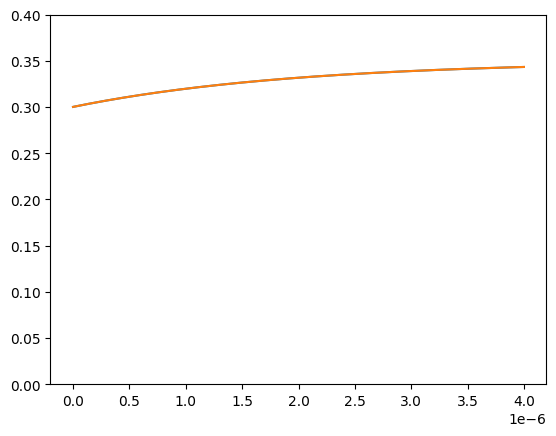

(array([ 3.33325619, -3.33233041]), array([ 1.        , -0.99967598]))
0.40646572929869434


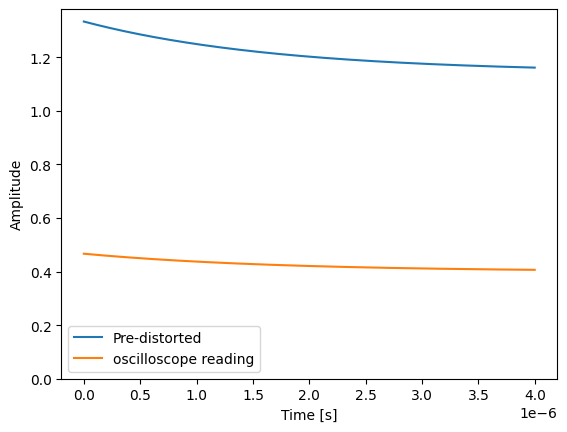

In [179]:

A = 350*1e-3 # mV
B = -50*1e-3 # mV
tau = 2000e-9 # ns

fs = 1.8e9 #Hz
Ts = 1/fs
#System Filter is just 1/Inverse

t = np.arange(0,4000e-9, Ts)

system_filter = sp.signal.lti([tau*(A+B), A],[tau,1])
print(system_filter)
print(len(t))
t,y = sp.signal.step(system_filter,T=t)
plt.plot(t, y)
plt.ylim(0,.4)

start=1
stop=-1

fit_params, _ = sp.optimize.curve_fit(f,t[start:stop], y[start:stop],p0=(100e-3,100e-3,100e-9))

A,B,tau = fit_params
print(fit_params)
plt.plot(t,f(t,A,B,tau))
plt.show()
# Inverse bilinear
inverse_IIR = sp.signal.bilinear(b=[tau,1],a=[tau*(A+B), A],fs=fs)

print(inverse_IIR)
inverse_IIR_LTI = sp.signal.lti(inverse_IIR[0], inverse_IIR[1])

ideal = 0.4 * np.ones_like(t)
pre_distorted = sp.signal.lfilter(inverse_IIR[0], inverse_IIR[1], x=ideal)

# raw_oscilloscope[0] = 0
# raw_oscilloscope[-1] = 0
pre_distorted_measured = sp.signal.lfilter(a=[tau,1][::-1],b=[tau*(A+B), A][::-1], x=pre_distorted)

print(pre_distorted_measured[-1])
# plt.plot(t, ideal,':',label='Ideal')
plt.plot(t,pre_distorted, label='Pre-distorted')

plt.plot(t,pre_distorted_measured,"-", label='oscilloscope reading')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.legend(loc='best')
plt.ylim(0,)

plt.show()